# 05 - Three controls on the results of 02 and 03

`02` and `03` each produced a headline, and each of them has an obvious alternative
explanation that has to be closed before the headline can be quoted. This notebook runs
the three controls. None of them is a new experiment; each one is an attempt to break a
result this folder has already produced.

## Control A - overlapping windows are not free after all

`02` step 3 pre-registered that training on every fourth window would cost less than
0.02 in job-level AP, because `headroom/` finding 1 argues that overlapping windows are
near-duplicates. **It cost 0.048** - 0.3934 down to 0.3450, a 12 % relative loss. The
pre-registration was wrong and every model in `02`, `03` and `04` is trained on the
thinned data, so all of those numbers are slight underestimates.

There are two readings and they lead to opposite conclusions:

* **The near-duplicate claim is wrong.** Overlapping windows carry real extra
  information, and `headroom/` finding 1 needs qualifying.
* **The near-duplicate claim is right, and 76,610 rows is simply too few.** At that size
  the model is starved, so any extra row helps regardless of how correlated it is. If so
  the penalty must **shrink** as the training set grows.

These make opposite predictions, so measuring the penalty at three training sizes
separates them.

**A1 (pre-registered).** The decimation penalty will shrink monotonically with training
size: the gap at 2,500 jobs will exceed the gap at 40,000 jobs.

## Control B - the GPU-only baseline in `02` was handicapped

`02` reported that training on the whole cluster beats training on GPU nodes alone when
both are tested on the same GPU jobs (0.5056 against 0.4404). That comparison is
**confounded**, and the confound is mine: GPU telemetry starts on **25 August** while
non-GPU telemetry starts on **30 June**, so a split taken at the 80th percentile of all
jobs pushes most GPU jobs late. The GPU-only arm was fitted on **606 failing GPU jobs**
where a GPU-native split would have given it about 1,700.

**B1 (pre-registered).** Given the fit and validation folds together - every GPU job
ending before the split, about 1,618 failing ones - the GPU-only arm will improve, but
training on the whole cluster will **still win** on telemetry.

## Control C - is the OOM memory signal a node-class artefact?

`03` found absolute node active memory separating `OUT_OF_MEMORY` jobs from matched
`COMPLETED` ones at **AUC 0.857 [0.846, 0.866]**, while the baseline-relative form that
`headroom/` identified fell to **0.611**. Absolute memory is exactly the kind of feature
that can be a machine identifier in disguise: a queue of large-memory nodes would
produce the same separation with no mechanism at all.

**C1 (pre-registered).** The separation will survive **within queue**: computed
separately inside each queue that holds at least 30 OOM jobs, the median AUC will stay
above 0.70.

## Control D - was the lead-time shape a confound?

`03` step 4 compared OOM windows against **all** `COMPLETED` windows and found the
separation inverted in sign (AUC 0.34-0.46) and decaying with lead time - the opposite
of `headroom/`'s flat profile. That comparison has an obvious defect: `COMPLETED`
windows are drawn from everywhere inside their jobs, and healthy jobs run far longer, so
a window late in a long healthy job has had hours to drift from its own baseline while a
typical OOM window has had minutes. The comparison measured **position inside the job**,
not the failure mechanism.

The fix is to compare like with like: matched controls, and OOM windows against
`COMPLETED` windows **at the same distance from their own job's end**.

**D1 (pre-registered).** Under matching, the baseline-relative separation will return to
the positive direction - AUC above 0.5 in every lead-time band - reversing the sign
reported in `03`.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

WINDOW, SNAP_S = 40, 30.0
FLOOR_S  = (WINDOW // 2 - 1) * SNAP_S
DEC      = 4
VAL_FRAC = 0.20
HORIZON_H = 2.0
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts_01 = json.load(open(DATA / "facts_01.json"))
FEATURES = facts_01["features"]
facts = {}

## Control A - the decimation penalty against training size

40,000 fit jobs are drawn once; the 10,000- and 2,500-job rungs are **nested subsets** of
that draw, so the three rungs differ only in size and not in which jobs they contain.
Their windows are read **undecimated**; the evaluation rows are the same test windows in
every arm, so only the training data changes.

In [2]:
t0 = time.time()
META = ["slurm_id", "state", "gpu_node", "split", "ttf_end", "w_idx", "t_end",
        "nodetypes", "numnodes"]
pf = pq.ParquetFile(DATA / "windows_all.parquet")

# the folds have to be rebuilt before the streaming read, so job ids can be filtered
jobs = pd.read_parquet(DATA / "jobs_all.parquet")
meta = pq.read_table(DATA / "windows_all.parquet",
                     columns=["slurm_id", "split", "t_end"]).to_pandas()
tr_j = (meta.loc[meta.split == "train"].groupby("slurm_id").t_end.max().sort_values())
val_ids = set(tr_j.index[int(len(tr_j) * (1 - VAL_FRAC)):])
fit_ids = np.array(sorted(set(tr_j.index) - val_ids))
del meta; gc.collect()

rng = np.random.default_rng(0)
K = [2_500, 10_000, 40_000]
big = rng.choice(fit_ids, size=min(max(K), len(fit_ids)), replace=False)
nested = {k: set(big[:k]) for k in K}
keep_ids = set(big)
print(f"fit pool {len(fit_ids):,} jobs | nested draws {K} | [{time.time()-t0:.0f}s]")

fit pool 60,383 jobs | nested draws [2500, 10000, 40000] | [1s]


In [3]:
t0 = time.time()
tr_chunks, te_chunks = [], []
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d = batch.to_pandas()
    tr_chunks.append(d[(d.split == "train") & d.slurm_id.isin(keep_ids)])
    te_chunks.append(d[(d.split == "test") & (d.w_idx % DEC == 0)])
TR = pd.concat(tr_chunks, ignore_index=True); del tr_chunks
TE = pd.concat(te_chunks, ignore_index=True); del te_chunks
gc.collect()
# string columns as categories: at 3.4 M undecimated rows the object dtype alone
# would cost more than the 36 feature columns put together
for df_ in (TR, TE):
    for c in ("state", "nodetypes", "split"):
        df_[c] = df_[c].astype("category")
print(f"train rows (undecimated, {len(keep_ids):,} jobs) {len(TR):,} | "
      f"test rows {len(TE):,} | [{time.time()-t0:.0f}s]  "
      f"{(TR.memory_usage(deep=True).sum()+TE.memory_usage(deep=True).sum())/1e9:.2f} GB")

def lab(df, H=HORIZON_H):
    return (df.state.isin(FAILURE_STATES).to_numpy() & (df.ttf_end.to_numpy() >= 0)
            & (df.ttf_end.to_numpy() <= H * 3600 - FLOOR_S)).astype(np.int8)

y_te = lab(TE)
def eval_on_test(m, cols, restrict=None):
    d = TE if restrict is None else TE[restrict]
    sc = m.predict_proba(d[cols])[:, 1]
    g = (pd.DataFrame({"slurm_id": d.slurm_id.to_numpy(),
                       "state": d.state.astype(str).to_numpy(), "score": sc})
           .groupby("slurm_id").agg(score=("score", "max"), state=("state", "first")))
    yj = g.state.isin(FAILURE_STATES).astype(int).to_numpy()
    return average_precision_score(yj, g.score.to_numpy()), float(yj.mean())

train rows (undecimated, 40,000 jobs) 3,393,441 | test rows 263,877 | [4s]  0.62 GB


In [4]:
t0 = time.time()
rows = []
for k in K:
    m_k = TR.slurm_id.isin(nested[k]).to_numpy()
    for thin, name in [(1, "every window"), (DEC, f"every {DEC}th window")]:
        sub = TR[m_k & (TR.w_idx % thin == 0).to_numpy()]
        m = lgb.LGBMClassifier(**PARAMS).fit(sub[FEATURES], lab(sub))
        ap, base = eval_on_test(m, FEATURES)
        rows.append(dict(k_jobs=k, thinning=name, fit_rows=len(sub), job_ap=ap))
    print(f"  k={k:>6,}  [{time.time()-t0:.0f}s]")
A = pd.DataFrame(rows)
A.to_csv(DATA / "decimation.csv", index=False)
piv = A.pivot(index="k_jobs", columns="thinning", values="job_ap")
piv["penalty"] = piv["every window"] - piv[f"every {DEC}th window"]
piv["rows_full"] = A[A.thinning == "every window"].set_index("k_jobs").fit_rows
print(piv.round(4).to_string())

a1 = piv.penalty.iloc[0] > piv.penalty.iloc[-1]
print()
print(f"A1  the decimation penalty shrinks with data : {'CONFIRMED' if a1 else 'REJECTED'}")
print(f"    {piv.penalty.iloc[0]:+.4f} at {K[0]:,} jobs  ->  "
      f"{piv.penalty.iloc[-1]:+.4f} at {K[-1]:,} jobs")
print(f"    (GPU-only, 76,610 rows, the penalty was +0.0484)")
facts.update(A1=bool(a1), penalty_small=float(piv.penalty.iloc[0]),
             penalty_large=float(piv.penalty.iloc[-1]))
del TR; gc.collect()

  k= 2,500  [8s]


  k=10,000  [25s]


  k=40,000  [83s]
thinning  every 4th window  every window  penalty  rows_full
k_jobs                                                      
2500                0.4168        0.3852  -0.0315     235832
10000               0.3984        0.3971  -0.0013     834071
40000               0.3837        0.3899   0.0061    3393441

A1  the decimation penalty shrinks with data : REJECTED
    -0.0315 at 2,500 jobs  ->  +0.0061 at 40,000 jobs
    (GPU-only, 76,610 rows, the penalty was +0.0484)


107

## Control B - a fair GPU-only baseline

Both arms now train on **every job that ended before the split** - fit and validation
together - and both are evaluated on the **same** GPU test jobs. The only difference left
is whether non-GPU jobs are allowed into the training set.

In [5]:
t0 = time.time()
tr2 = []
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d = batch.to_pandas()
    tr2.append(d[(d.split == "train") & (d.w_idx % DEC == 0)])
TR2 = pd.concat(tr2, ignore_index=True); del tr2; gc.collect()
TR2 = TR2.merge(jobs[["slurm_id", "start_date", "numcores"]], on="slurm_id", how="left")
TE = TE.merge(jobs[["slurm_id", "start_date", "numcores"]], on="slurm_id", how="left")

def add_ctx(df):
    el = (df.t_end - df.start_date).dt.total_seconds().to_numpy()
    df["elapsed_h"] = el / 3600.0
    df["sec_into_hour"] = el % 3600.0
    df["sec_to_next_hour"] = 3600.0 - (el % 3600.0)
    df["elapsed_hours_floor"] = np.floor(el / 3600.0)
    df["queue_code"] = df.nodetypes.astype(str).astype("category").cat.codes
    return df
TR2, TE = add_ctx(TR2), add_ctx(TE)
C7 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"]
SETS = {"T36 telemetry": FEATURES, "C7  context": C7}

gpu_te = (TE.gpu_node == 1).to_numpy()
gpu_tr = (TR2.gpu_node == 1).to_numpy()
nfail_gpu = TR2.loc[gpu_tr & TR2.state.isin(FAILURE_STATES), "slurm_id"].nunique()
print(f"GPU training jobs {TR2.loc[gpu_tr,'slurm_id'].nunique():,} "
      f"({nfail_gpu:,} failing) | GPU test jobs {TE.loc[gpu_te,'slurm_id'].nunique():,}")
print(f"[{time.time()-t0:.0f}s]")

GPU training jobs 9,915 (1,618 failing) | GPU test jobs 3,043
[3s]


In [6]:
rows = []
for name, cols in SETS.items():
    for arm, m_tr in [("GPU only", gpu_tr), ("whole cluster", np.ones(len(TR2), bool))]:
        sub = TR2[m_tr]
        m = lgb.LGBMClassifier(**PARAMS).fit(sub[cols], lab(sub))
        ap, base = eval_on_test(m, cols, restrict=gpu_te)
        rows.append(dict(features=name, trained_on=arm, fit_jobs=sub.slurm_id.nunique(),
                         fit_rows=len(sub), gpu_test_job_ap=ap, base=base,
                         lift=ap / base))
Bm = pd.DataFrame(rows)
Bm.to_csv(DATA / "fair_gpu_baseline.csv", index=False)
print(Bm.round(4).to_string(index=False))

pv = Bm.pivot(index="features", columns="trained_on", values="gpu_test_job_ap")
b1 = bool(pv.loc["T36 telemetry", "whole cluster"] > pv.loc["T36 telemetry", "GPU only"])
print()
print(f"B1  cluster training still wins on telemetry : {'CONFIRMED' if b1 else 'REJECTED'}")
print(pv.round(4).to_string())
print(f"    02 compared 0.4404 (GPU only, fit fold) with 0.5056 (cluster); the fair "
      f"GPU-only arm is {pv.loc['T36 telemetry','GPU only']:.4f}")
facts.update(B1=b1, fair_gpu={c: {r: float(pv.loc[r, c]) for r in pv.index}
                              for c in pv.columns})
del TR2; gc.collect()

     features    trained_on  fit_jobs  fit_rows  gpu_test_job_ap   base   lift
T36 telemetry      GPU only      9915    226479           0.4444 0.1571 2.8293
T36 telemetry whole cluster     75476   1789087           0.4905 0.1571 3.1225
  C7  context      GPU only      9915    226479           0.5022 0.1571 3.1971
  C7  context whole cluster     75476   1789087           0.4760 0.1571 3.0302

B1  cluster training still wins on telemetry : CONFIRMED
trained_on     GPU only  whole cluster
features                              
C7  context      0.5022         0.4760
T36 telemetry    0.4444         0.4905
    02 compared 0.4404 (GPU only, fit fold) with 0.5056 (cluster); the fair GPU-only arm is 0.4444


127

## Control C - is the OOM memory separation just the machine?

Computed inside each queue separately. Within a queue the node class is essentially
fixed, so a separation that survives cannot be "OOM jobs sit on large-memory machines".
The comparison is `OUT_OF_MEMORY` windows against `COMPLETED` windows in the final five
minutes of each job, exactly as in `03`.

In [7]:
t0 = time.time()
cols_needed = ["slurm_id", "state", "nodetypes", "ttf_end", "numnodes",
               "mem_active__mean", "mem_free__mean"]
chunks = []
for batch in pf.iter_batches(batch_size=400_000, columns=cols_needed):
    d = batch.to_pandas()
    chunks.append(d[(d.ttf_end <= 300) & d.state.isin(["OUT_OF_MEMORY", "COMPLETED"])])
L = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
print(f"{len(L):,} final-five-minute windows | "
      f"OOM jobs {L.loc[L.state=='OUT_OF_MEMORY','slurm_id'].nunique():,} | "
      f"[{time.time()-t0:.0f}s]")

def group_index(g):
    """Row indices per group in one pass - building it with a mask per group is
    O(groups x rows) and does not finish at cluster scale."""
    o = np.argsort(g, kind="stable")
    gs = g[o]
    starts = np.flatnonzero(np.r_[True, gs[1:] != gs[:-1]])
    return [o[a:b] for a, b in zip(starts, np.r_[starts[1:], len(g)])]

def auc_ci(pos, neg, gp, gn, n_boot=150, seed=0):
    """Rank-sum AUC, bootstrapped over JOBS - windows inside a job are not independent."""
    def auc(a, b):
        r = rankdata(np.concatenate([a, b]))
        return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))
    point = auc(pos, neg)
    rng = np.random.default_rng(seed)
    ip, iN = group_index(gp), group_index(gn)
    out = []
    for _ in range(n_boot):
        a = np.concatenate([ip[k] for k in rng.integers(0, len(ip), len(ip))])
        b = np.concatenate([iN[k] for k in rng.integers(0, len(iN), len(iN))])
        out.append(auc(pos[a], neg[b]))
    return point, *np.percentile(out, [2.5, 97.5])

MAX_CTRL = 1_500          # controls per queue: the bootstrap is linear in this
rng = np.random.default_rng(0)
rows = []
for q, d in L.groupby("nodetypes", observed=True):
    P = d[d.state == "OUT_OF_MEMORY"]; N = d[d.state == "COMPLETED"]
    if P.slurm_id.nunique() < 30 or N.slurm_id.nunique() < 30:
        continue
    if N.slurm_id.nunique() > MAX_CTRL:
        keep = rng.choice(N.slurm_id.unique(), MAX_CTRL, replace=False)
        N = N[N.slurm_id.isin(keep)]
    a, lo_, hi_ = auc_ci(P.mem_active__mean.to_numpy(), N.mem_active__mean.to_numpy(),
                         P.slurm_id.to_numpy(), N.slurm_id.to_numpy())
    rows.append(dict(queue=q, auc=a, lo=lo_, hi=hi_, oom_jobs=P.slurm_id.nunique(),
                     completed_jobs=N.slurm_id.nunique()))
Q = pd.DataFrame(rows).sort_values("auc", ascending=False)
Q.to_csv(DATA / "oom_by_queue.csv", index=False)
print(Q.round(4).to_string(index=False))
med = float(Q.auc.median())
c1 = med > 0.70
print()
print(f"C1  separation survives within queue : {'CONFIRMED' if c1 else 'REJECTED'}")
print(f"    median AUC across {len(Q)} queues {med:.4f}  "
      f"(pooled across all queues it was 0.8566)")
facts.update(C1=bool(c1), oom_auc_by_queue_median=med, oom_queues=int(len(Q)))

79,841 final-five-minute windows | OOM jobs 1,242 | [1s]


          queue    auc     lo     hi  oom_jobs  completed_jobs
         shared 0.8443 0.8293 0.8600       828            1500
shared_52c_384g 0.8167 0.7436 0.8816        32              80
         normal 0.7754 0.7465 0.8023       325            1500

C1  separation survives within queue : CONFIRMED
    median AUC across 3 queues 0.8167  (pooled across all queues it was 0.8566)


## Control D - the lead-time shape, with matched controls

`COMPLETED` controls are drawn from the same queues and the same runtime band as the OOM
jobs, and every band compares windows that sit the **same distance from their own job's
end**. Baselines are per `(job, node)` series, as everywhere else.

In [8]:
t0 = time.time()
J = jobs.copy()
J["runtime_s"] = (J.last_ts - J.first_ts).dt.total_seconds()
oomj = J[(J.state == "OUT_OF_MEMORY") & (J.runtime_s >= 600)]
lo_r, hi_r = oomj.runtime_s.min(), oomj.runtime_s.max()
ctrl = J[(J.state == "COMPLETED") & J.runtime_s.between(lo_r, hi_r)
         & J.nodetypes.isin(oomj.nodetypes.unique())]
ctrl = ctrl.sample(min(len(ctrl), 4_000), random_state=0)
keep_d = set(oomj.slurm_id) | set(ctrl.slurm_id)
print(f"OOM {len(oomj):,} vs matched COMPLETED {len(ctrl):,} | runtime band "
      f"{lo_r/60:.0f}-{hi_r/60:.0f} min")

cols_d = ["slurm_id", "node", "state", "ttf_end", "w_idx", "mem_active__mean"]
chunks = []
for batch in pf.iter_batches(batch_size=400_000, columns=cols_d):
    d = batch.to_pandas()
    chunks.append(d[d.slurm_id.isin(keep_d)])
D = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
D = D.sort_values(["slurm_id", "node", "w_idx"], ignore_index=True)
b = D.groupby(["slurm_id", "node"], observed=True).mem_active__mean.first().rename("base")
D = D.merge(b, on=["slurm_id", "node"], how="left")
D["delta"] = D.mem_active__mean - D.base
print(f"{len(D):,} windows | {D.slurm_id.nunique():,} jobs | [{time.time()-t0:.0f}s]")

OOM 1,922 vs matched COMPLETED 4,000 | runtime band 10-5680 min


261,261 windows | 4,763 jobs | [2s]


In [9]:
rows = []
for a, b_ in [(0, 300), (300, 900), (900, 1800), (1800, 3600), (3600, 7200)]:
    band = D[(D.ttf_end >= a) & (D.ttf_end < b_)]
    P = band[band.state == "OUT_OF_MEMORY"]; N = band[band.state == "COMPLETED"]
    if P.slurm_id.nunique() < 30 or N.slurm_id.nunique() < 30:
        continue
    for kind, col in [("absolute", "mem_active__mean"), ("baseline-relative", "delta")]:
        auc, l_, h_ = auc_ci(P[col].to_numpy(), N[col].to_numpy(),
                             P.slurm_id.to_numpy(), N.slurm_id.to_numpy(), n_boot=150)
        rows.append(dict(band=f"{a//60}-{b_//60} min", lead_min=a / 60, kind=kind,
                         auc=auc, lo=l_, hi=h_, sep=abs(auc - .5),
                         oom_jobs=P.slurm_id.nunique(), ctrl_jobs=N.slurm_id.nunique()))
Dl = pd.DataFrame(rows)
Dl.to_csv(DATA / "oom_leadtime_matched.csv", index=False)
print(Dl.round(4).to_string(index=False))

rel = Dl[Dl.kind == "baseline-relative"]
d1 = bool((rel.auc > 0.5).all())
print()
print(f"D1  matching restores the positive direction : {'CONFIRMED' if d1 else 'REJECTED'}")
print(f"    baseline-relative AUC by band: "
      f"{', '.join(f'{v:.3f}' for v in rel.auc)}")
print(f"    03 reported 0.361, 0.339, 0.393, 0.385, 0.456 without matching")
absr = Dl[Dl.kind == "absolute"]
print(f"    absolute AUC by band:         "
      f"{', '.join(f'{v:.3f}' for v in absr.auc)}")
facts.update(D1=d1, leadtime_matched_rel=[float(v) for v in rel.auc],
             leadtime_matched_abs=[float(v) for v in absr.auc],
             leadtime_matched_spread=float(absr.sep.max() - absr.sep.min()))

      band  lead_min              kind    auc     lo     hi    sep  oom_jobs  ctrl_jobs
   0-5 min       0.0          absolute 0.8580 0.8435 0.8702 0.3580      1242       3421
   0-5 min       0.0 baseline-relative 0.4462 0.4220 0.4682 0.0538      1242       3421
  5-15 min       5.0          absolute 0.8471 0.8291 0.8600 0.3471      1038       3246
  5-15 min       5.0 baseline-relative 0.4353 0.4005 0.4632 0.0647      1038       3246
 15-30 min      15.0          absolute 0.8437 0.8276 0.8584 0.3437       924       2702
 15-30 min      15.0 baseline-relative 0.4328 0.4068 0.4601 0.0672       924       2702
 30-60 min      30.0          absolute 0.8219 0.8005 0.8383 0.3219       867       2436
 30-60 min      30.0 baseline-relative 0.4933 0.4607 0.5276 0.0067       867       2436
60-120 min      60.0          absolute 0.7869 0.7689 0.8099 0.2869       508       1710
60-120 min      60.0 baseline-relative 0.5222 0.4862 0.5660 0.0222       508       1710

D1  matching restores the posit

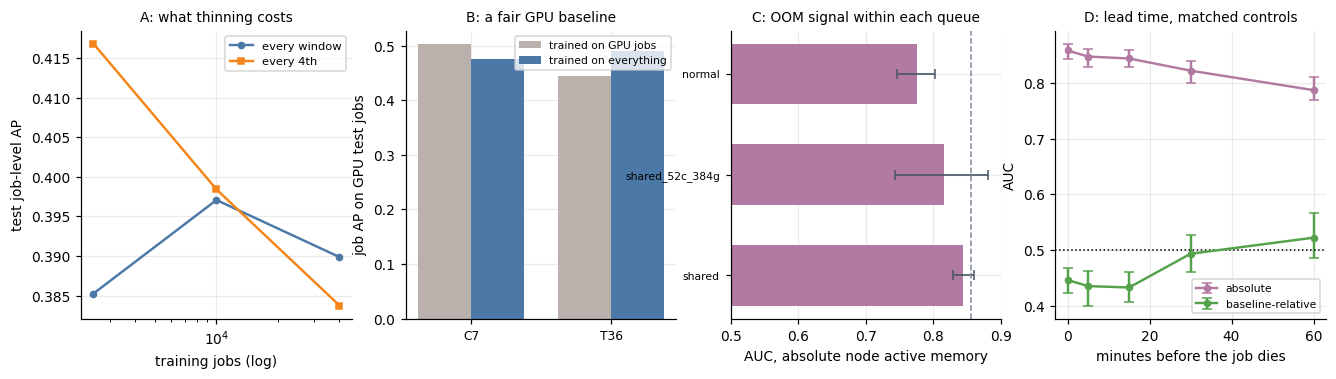

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14.6, 3.4))

ax = axes[0]
ax.plot(piv.index, piv["every window"], marker="o", ms=4, color="#4c78a8",
        label="every window", lw=1.6)
ax.plot(piv.index, piv[f"every {DEC}th window"], marker="s", ms=4, color="#f58518",
        label=f"every {DEC}th", lw=1.6)
ax.set_xscale("log"); ax.set_xlabel("training jobs (log)")
ax.set_ylabel("test job-level AP"); ax.legend(fontsize=7.5)
ax.set_title("A: what thinning costs", fontsize=9)

ax = axes[1]
x = np.arange(len(pv.index))
ax.bar(x - .19, pv["GPU only"], .38, label="trained on GPU jobs", color="#bab0ac")
ax.bar(x + .19, pv["whole cluster"], .38, label="trained on everything", color="#4c78a8")
ax.set_xticks(x); ax.set_xticklabels([c.split()[0] for c in pv.index], fontsize=8)
ax.set_ylabel("job AP on GPU test jobs"); ax.legend(fontsize=7)
ax.set_title("B: a fair GPU baseline", fontsize=9)

ax = axes[2]
y = np.arange(len(Q))
ax.barh(y, Q.auc - .5, left=.5, color="#b279a2", height=.6)
ax.errorbar(Q.auc, y, xerr=[Q.auc - Q.lo, Q.hi - Q.auc], fmt="none",
            ecolor="#495666", elinewidth=1.1, capsize=3)
ax.axvline(.5, color="k", lw=1); ax.axvline(.8566, color="#7b8899", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(Q.queue, fontsize=7)
ax.set_xlabel("AUC, absolute node active memory")
ax.set_title("C: OOM signal within each queue", fontsize=9)

ax = axes[3]
for kind, c in [("absolute", "#b279a2"), ("baseline-relative", "#54a24b")]:
    dd = Dl[Dl.kind == kind]
    ax.errorbar(dd.lead_min, dd.auc, yerr=[dd.auc - dd.lo, dd.hi - dd.auc], marker="o",
                ms=4, lw=1.6, color=c, label=kind, capsize=3)
ax.axhline(.5, color="k", ls=":", lw=1)
ax.set_xlabel("minutes before the job dies"); ax.set_ylabel("AUC")
ax.legend(fontsize=7); ax.set_title("D: lead time, matched controls", fontsize=9)
save(fig, "05_controls.png"); plt.show()

## What survives

Read the three verdicts above together with the results they are testing. A control that
rejects is not a failure of the notebook - it is the reason the headline can or cannot
be written down.

In [11]:
json.dump(facts, open(DATA / "facts_05.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:26s} {v}")

A1                         False
penalty_small              -0.03154739897879277
penalty_large              0.0061189131850798995
B1                         True
fair_gpu                   {'GPU only': {'C7  context': 0.5022130830357882, 'T36 telemetry': 0.44442873017455614}, 'whole cluster': {'C7  context': 0.47599671476339545, 'T36 telemetry': 0.49048090934507876}}
C1                         True
oom_auc_by_queue_median    0.8167438271604939
oom_queues                 3
D1                         False
leadtime_matched_rel       [0.44618138018867726, 0.43529597123812774, 0.4327655740907596, 0.49330154998506365, 0.5221773838037029]
leadtime_matched_abs       [0.8580293072691978, 0.8471314505976586, 0.8436703333774591, 0.8218612320421483, 0.7868689904524707]
leadtime_matched_spread    0.07116031681672708
